# Microdemo 3: ETFs, volume e retornos com Copilot

Este notebook foi preparado para uma demonstração ao vivo no VS Code com GitHub Copilot.

A ideia não é construir um modelo sofisticado. A ideia é mostrar um fluxo profissional simples:

1. baixar dados reais de mercado;
2. calcular métricas financeiras transparentes;
3. visualizar padrões de preço, risco e liquidez;
4. editar pequenos trechos de código com ajuda do Copilot;
5. validar se o resultado faz sentido.



## O que vamos medir

Para cada ETF, usamos preços diários e volume negociado.

O retorno logarítmico diário é:

$$
r_t = \log\left(\frac{P_t}{P_{t-1}}\right)
$$

A volatilidade realizada anualizada, estimada a partir de retornos diários, é:

$$
\sigma = \sqrt{252}\,\mathrm{sd}(r_t)
$$

O volume financeiro aproximado é:

$$
DollarVolume_t = P_t \times Volume_t
$$

E o volume relativo compara o volume do dia contra sua média móvel:

$$
VolumeRelativo_t = \frac{Volume_t}{MM_{20}(Volume_t)}
$$


In [1]:
from __future__ import annotations

import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams["font.family"] = "Arial"
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.titleweight"] = "bold"

CORES = [
    "#A31229",  # vermelho FURG
    "#C77824",  # laranja FURG
    "#E5AD2A",  # amarelo FURG
    "#246A73",
    "#2E5EAA",
    "#4C4C4C",
    "#7A5195",
    "#2F855A",
]
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=CORES)


## 1. Universo de ETFs

A lista abaixo mistura ações americanas, ações internacionais, emergentes, renda fixa longa, ouro e real estate.

Isso ajuda a comparar ativos que reagem de formas diferentes a risco, juros, liquidez e fluxo de investidores.


In [2]:
etfs = ["SPY", "QQQ", "IWM", "EFA", "EEM", "TLT", "GLD", "VNQ"]

data_inicio = "2010-01-01"
janela_volume = 20
limite_volume_anormal = 2.5

descricoes = {
    "SPY": "S&P 500",
    "QQQ": "Nasdaq 100",
    "IWM": "Russell 2000",
    "EFA": "Ações desenvolvidas ex-EUA",
    "EEM": "Mercados emergentes",
    "TLT": "Treasuries longos",
    "GLD": "Ouro",
    "VNQ": "Real estate EUA",
}

pd.DataFrame({"ticker": etfs, "descrição": [descricoes.get(t, "") for t in etfs]})


,ticker,descrição
0,SPY,S&P 500
1,QQQ,Nasdaq 100
2,IWM,Russell 2000
3,EFA,Ações desenvolvidas ex-EUA
4,EEM,Mercados emergentes
5,TLT,Treasuries longos
6,GLD,Ouro
7,VNQ,Real estate EUA


## 2. Download e organização dos dados

O `yfinance` retorna uma tabela larga. A célula abaixo transforma os dados em dois objetos simples:

- `precos`: preço de fechamento ajustado por ETF;
- `volumes`: quantidade de cotas negociadas por ETF.

A função também verifica casos comuns: download vazio, ticker sem dados válidos ou coluna ausente.


In [3]:
def baixar_precos_e_volume(tickers: list[str], inicio: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Baixa preços e volumes do yfinance e devolve tabelas largas por ticker."""
    raw = yf.download(
        tickers,
        start=inicio,
        auto_adjust=True,
        progress=False,
        threads=True,
    )

    if raw.empty:
        raise RuntimeError(
            "O yfinance retornou uma tabela vazia. Verifique a conexão ou tente novamente."
        )

    if isinstance(raw.columns, pd.MultiIndex):
        primeiro_nivel = raw.columns.get_level_values(0)
        segundo_nivel = raw.columns.get_level_values(1)

        if "Close" in primeiro_nivel:
            close = raw["Close"].copy()
            volume = raw["Volume"].copy()
        elif "Close" in segundo_nivel:
            close = raw.xs("Close", axis=1, level=1).copy()
            volume = raw.xs("Volume", axis=1, level=1).copy()
        else:
            raise RuntimeError("Não encontrei colunas de preço no formato esperado.")
    else:
        if "Close" not in raw.columns or "Volume" not in raw.columns:
            raise RuntimeError("Não encontrei colunas Close e Volume no download.")
        close = raw[["Close"]].copy()
        volume = raw[["Volume"]].copy()
        close.columns = [tickers[0]]
        volume.columns = [tickers[0]]

    tickers_validos = [t for t in tickers if t in close.columns and not close[t].dropna().empty]
    tickers_faltantes = [t for t in tickers if t not in tickers_validos]

    if tickers_faltantes:
        print("Atenção: sem dados válidos para:", ", ".join(tickers_faltantes))

    if not tickers_validos:
        raise RuntimeError("Nenhum ticker retornou dados válidos.")

    close = close[tickers_validos].sort_index().dropna(how="all")
    volume = volume[tickers_validos].sort_index().reindex(close.index).fillna(0)

    return close, volume


precos, volumes = baixar_precos_e_volume(etfs, data_inicio)
print(f"Amostra: {precos.index.min().date()} a {precos.index.max().date()}")
print(f"Observações: {len(precos):,} dias úteis | ETFs válidos: {len(precos.columns)}")
precos.tail()


Amostra: 2010-01-04 a 2026-05-01
Observações: 4,107 dias úteis | ETFs válidos: 8


Ticker,SPY,QQQ,IWM,EFA,EEM,TLT,GLD,VNQ
Date,,,,,,,,
2026-04-27,715.169983,664.229980,277.140015,101.379997,63.639999,85.962570,429.890015,94.779999
2026-04-28,711.690002,657.549988,273.910004,100.959999,62.990002,86.052246,421.910004,95.650002
2026-04-29,711.580017,661.570007,272.079987,99.930000,62.689999,85.384705,417.410004,94.900002
2026-04-30,718.659973,667.739990,277.970001,102.320000,63.990002,85.305000,423.660004,96.330002
2026-05-01,720.650024,674.150024,279.279999,102.099998,64.129997,85.610001,423.179993,96.059998


## 3. Retornos, risco e volume financeiro

Aqui calculamos as principais variáveis usadas no restante do notebook.

A escolha de retornos logarítmicos facilita somar retornos ao longo do tempo. Para uma demonstração curta, o mais importante é que a transformação fique visível e auditável.


In [4]:
retornos = np.log(precos / precos.shift(1))
volatilidade_mensal = retornos.resample("ME").std() * math.sqrt(252)
volume_financeiro = precos * volumes
volume_relativo = volumes / volumes.rolling(janela_volume).mean()

primeiro_preco = precos.apply(lambda coluna: coluna.dropna().iloc[0])
precos_normalizados = precos.divide(primeiro_preco, axis=1) * 100

print("Objetos criados:")
print("- retornos")
print("- volatilidade_mensal")
print("- volume_financeiro")
print("- volume_relativo")


Objetos criados:
- retornos
- volatilidade_mensal
- volume_financeiro
- volume_relativo


## 4. Preços normalizados

O gráfico abaixo responde a uma pergunta simples: se todos os ETFs começassem em 100 no início da amostra, como teriam evoluído?


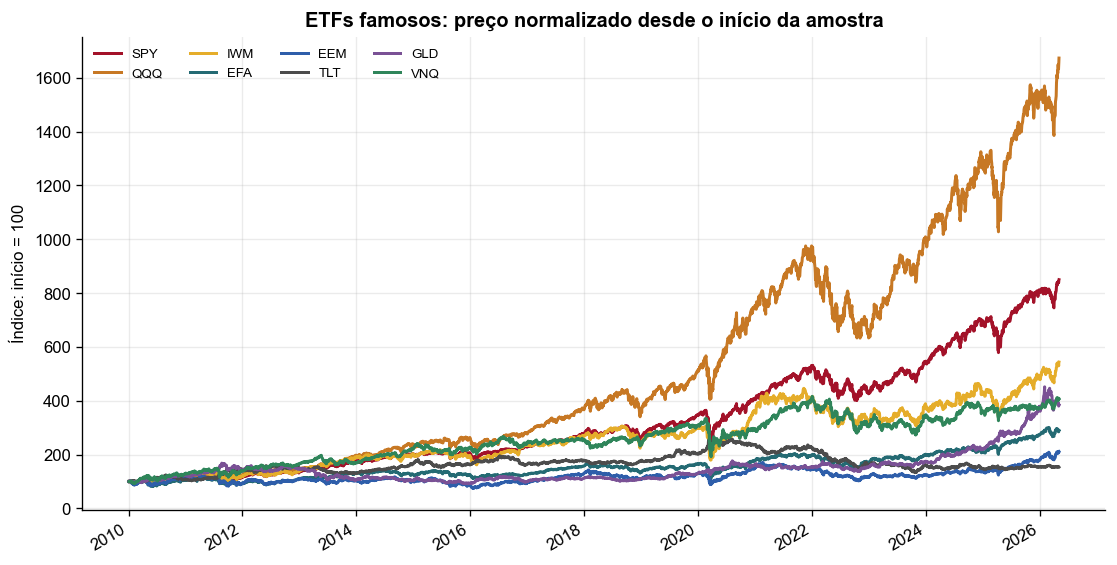

In [5]:
fig, ax = plt.subplots(figsize=(11, 5.8))
precos_normalizados.plot(ax=ax, linewidth=1.8)
ax.set_title("ETFs famosos: preço normalizado desde o início da amostra")
ax.set_ylabel("Índice: início = 100")
ax.set_xlabel("")
ax.legend(ncol=4, fontsize=8, frameon=False)
plt.show()


## 5. Volatilidade realizada mensal

A volatilidade mensal realizada aproxima o risco observado dentro de cada mês.

Meses de estresse costumam aparecer como picos. Isso ajuda a conectar dados financeiros com narrativa econômica sem precisar construir um modelo complexo.


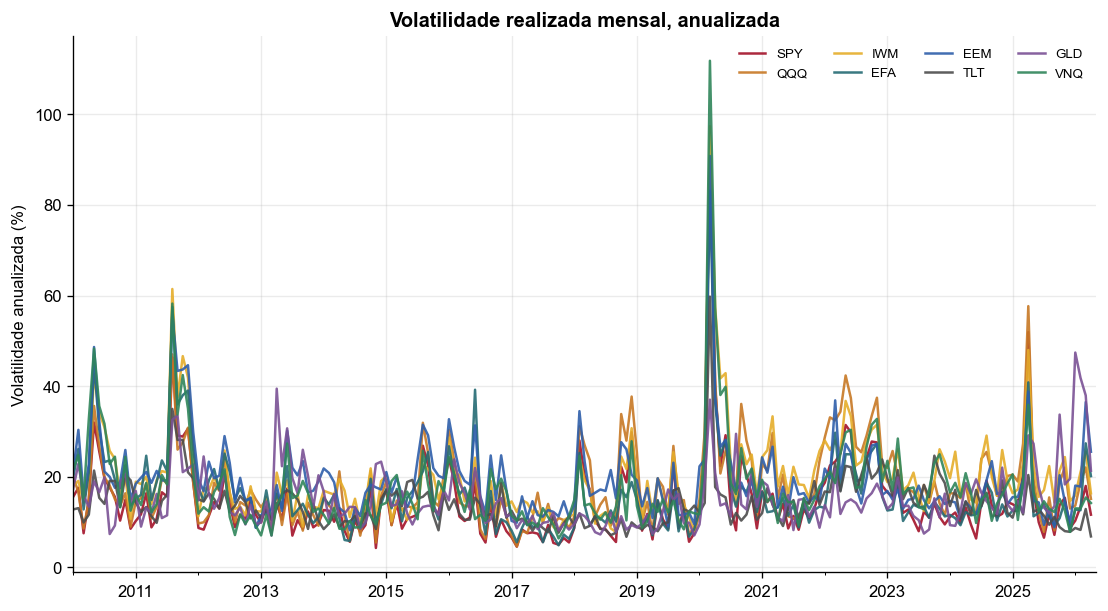

In [6]:
fig, ax = plt.subplots(figsize=(11, 5.8))
(volatilidade_mensal * 100).plot(ax=ax, linewidth=1.5, alpha=0.9)
ax.set_title("Volatilidade realizada mensal, anualizada")
ax.set_ylabel("Volatilidade anualizada (%)")
ax.set_xlabel("")
ax.legend(ncol=4, fontsize=8, frameon=False)
plt.show()


## 6. Volume financeiro ao longo dos anos

Volume bruto em cotas pode ser enganoso, porque ETFs têm preços diferentes.

Por isso usamos uma aproximação de volume financeiro diário:

$$
DollarVolume_t = P_t \times Volume_t
$$

A média anual dessa variável mostra como alguns ETFs viraram infraestrutura de mercado.


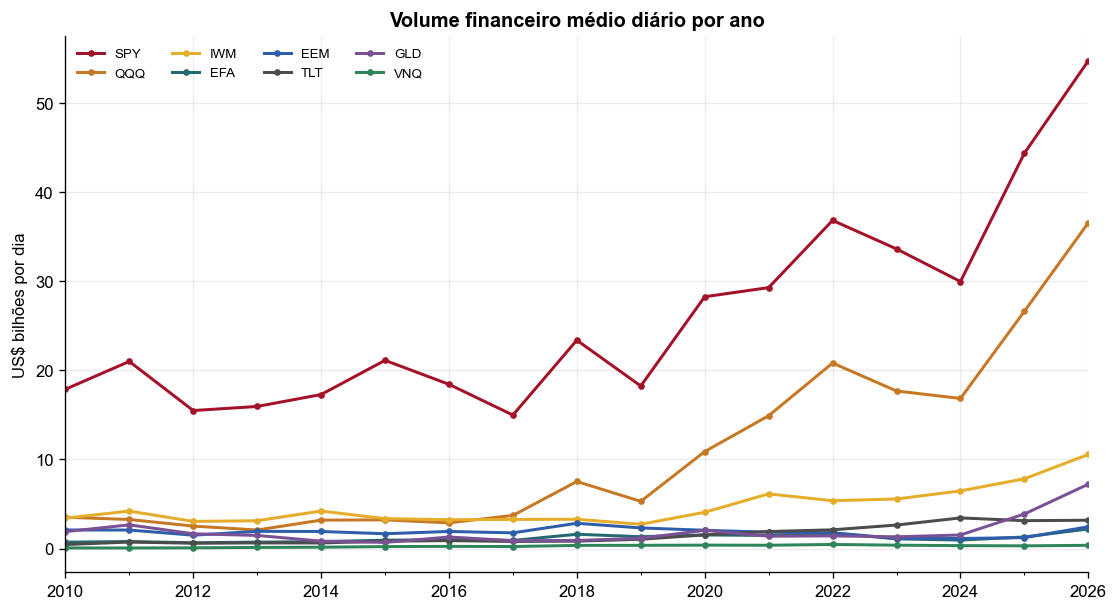

In [7]:
volume_financeiro_anual = volume_financeiro.resample("YE").mean() / 1_000_000_000

fig, ax = plt.subplots(figsize=(11, 5.8))
volume_financeiro_anual.plot(ax=ax, linewidth=1.8, marker="o", markersize=3)
ax.set_title("Volume financeiro médio diário por ano")
ax.set_ylabel("US$ bilhões por dia")
ax.set_xlabel("")
ax.legend(ncol=4, fontsize=8, frameon=False)
plt.show()


## 7. Dias de volume anormal

Agora procuramos dias em que o volume ficou muito acima do normal para o próprio ETF.

Um dia com `volume_relativo = 3` significa que o volume foi aproximadamente três vezes a média móvel recente.


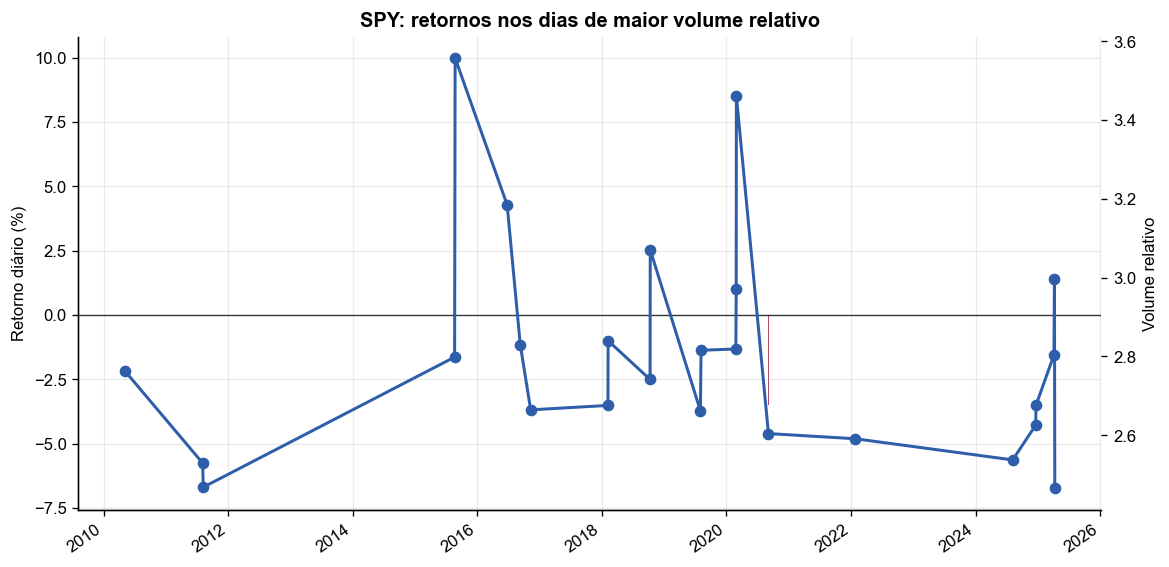

,retorno_pct,volume_relativo,volume_financeiro_bi
Date,,,
2020-02-27,-4.60,2.97,77.31
2020-02-28,-0.42,3.46,104.23
2020-09-03,-3.50,2.60,47.20
2022-01-24,0.42,2.59,104.47
2024-08-05,-2.96,2.54,74.12
2024-12-18,-3.03,2.63,62.35
2024-12-20,1.19,2.68,73.25
2025-04-04,-6.03,2.80,108.89
2025-04-07,-0.18,3.00,127.96


In [8]:
ticker_evento = "SPY"
numero_dias_extremos = 25

dados_evento = pd.DataFrame(
    {
        "retorno": retornos[ticker_evento],
        "volume_relativo": volume_relativo[ticker_evento],
        "volume_financeiro_bi": volume_financeiro[ticker_evento] / 1_000_000_000,
    }
).dropna()

dias_extremos = (
    dados_evento.nlargest(numero_dias_extremos, "volume_relativo")
    .sort_index()
    .assign(retorno_pct=lambda df: df["retorno"] * 100)
)

cores_barras = np.where(dias_extremos["retorno_pct"] >= 0, "#2F855A", "#A31229")

fig, ax1 = plt.subplots(figsize=(11, 5.8))
ax1.bar(dias_extremos.index, dias_extremos["retorno_pct"], color=cores_barras, alpha=0.78)
ax1.axhline(0, color="#333333", linewidth=0.8)
ax1.set_ylabel("Retorno diário (%)")
ax1.set_title(f"{ticker_evento}: retornos nos dias de maior volume relativo")

ax2 = ax1.twinx()
ax2.plot(
    dias_extremos.index,
    dias_extremos["volume_relativo"],
    color="#2E5EAA",
    marker="o",
    linewidth=1.8,
)
ax2.set_ylabel("Volume relativo")
ax2.grid(False)

fig.autofmt_xdate(rotation=35)
plt.show()

dias_extremos[["retorno_pct", "volume_relativo", "volume_financeiro_bi"]].round(2).tail(10)


## 8. Volume em dias de alta versus dias de queda

Uma pergunta simples e poderosa:

$$
\bar V^+ = E[V_t \mid r_t > 0], \quad
\bar V^- = E[V_t \mid r_t < 0]
$$

Ou seja: o ETF negocia mais em dias de alta ou em dias de queda?


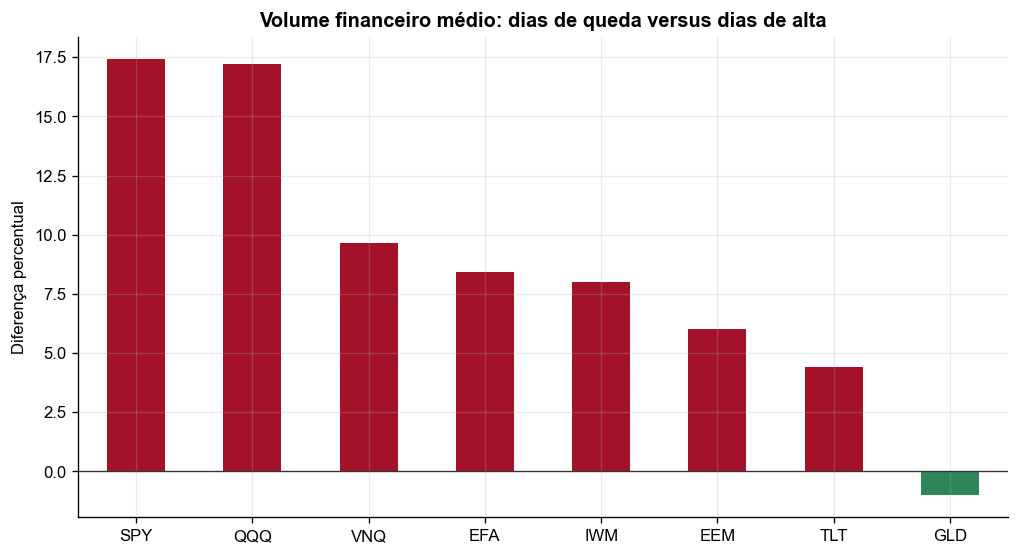

,volume_alta_bi,volume_queda_bi,dif_queda_vs_alta_pct
ticker,,,
SPY,22.99,27.00,17.44
QQQ,8.96,10.50,17.20
VNQ,0.25,0.28,9.63
EFA,1.08,1.17,8.41
IWM,4.30,4.65,8.01
EEM,1.79,1.90,6.03
TLT,1.40,1.46,4.41
GLD,1.69,1.67,-1.02


In [9]:
comparacao_volume = []

for ticker in precos.columns:
    dados = pd.DataFrame(
        {
            "retorno": retornos[ticker],
            "volume_financeiro": volume_financeiro[ticker],
        }
    ).dropna()

    volume_alta = dados.loc[dados["retorno"] > 0, "volume_financeiro"].mean()
    volume_queda = dados.loc[dados["retorno"] < 0, "volume_financeiro"].mean()

    comparacao_volume.append(
        {
            "ticker": ticker,
            "volume_alta_bi": volume_alta / 1_000_000_000,
            "volume_queda_bi": volume_queda / 1_000_000_000,
            "dif_queda_vs_alta_pct": (volume_queda / volume_alta - 1) * 100,
        }
    )

comparacao_volume = pd.DataFrame(comparacao_volume).set_index("ticker")
comparacao_volume = comparacao_volume.sort_values("dif_queda_vs_alta_pct", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5.2))
cores = np.where(comparacao_volume["dif_queda_vs_alta_pct"] >= 0, "#A31229", "#2F855A")
comparacao_volume["dif_queda_vs_alta_pct"].plot(kind="bar", ax=ax, color=cores)
ax.axhline(0, color="#333333", linewidth=0.8)
ax.set_title("Volume financeiro médio: dias de queda versus dias de alta")
ax.set_ylabel("Diferença percentual")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.show()

comparacao_volume.round(2)


## 9. Retorno absoluto e atenção do mercado

Outra forma de olhar volume é perguntar se dias de maior negociação coincidem com movimentos absolutos maiores.

Aqui usamos o retorno absoluto como proxy simples de “tamanho do movimento”.


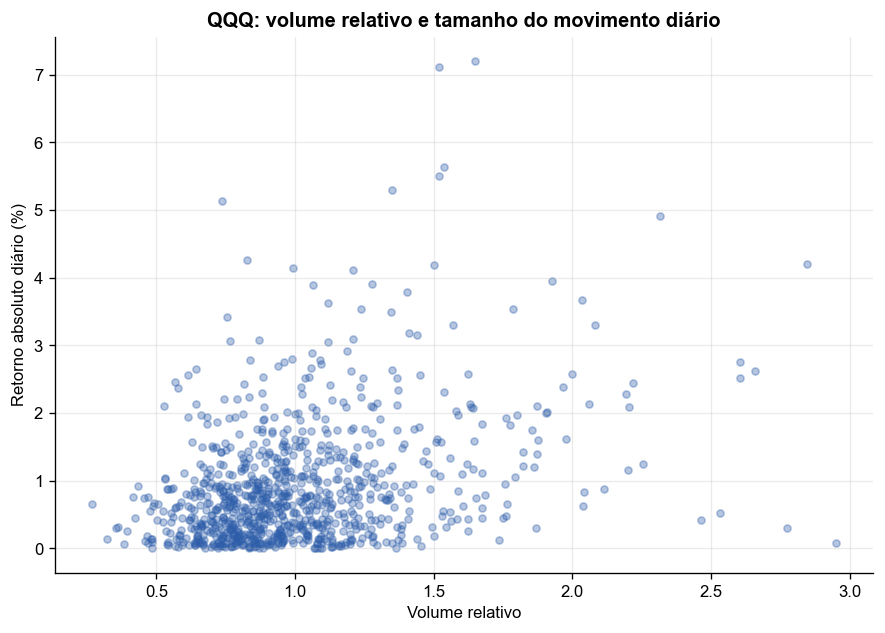

Correlação simples entre volume relativo e retorno absoluto: 0.37


In [10]:
ticker_scatter = "QQQ"

dados_scatter = pd.DataFrame(
    {
        "retorno_abs_pct": retornos[ticker_scatter].abs() * 100,
        "volume_relativo": volume_relativo[ticker_scatter],
    }
).dropna()

amostra_scatter = dados_scatter.sample(
    n=min(900, len(dados_scatter)),
    random_state=42,
)

fig, ax = plt.subplots(figsize=(8.8, 5.8))
ax.scatter(
    amostra_scatter["volume_relativo"],
    amostra_scatter["retorno_abs_pct"],
    s=18,
    alpha=0.35,
    color="#2E5EAA",
)
ax.set_title(f"{ticker_scatter}: volume relativo e tamanho do movimento diário")
ax.set_xlabel("Volume relativo")
ax.set_ylabel("Retorno absoluto diário (%)")
plt.show()

correlacao = dados_scatter.corr().loc["volume_relativo", "retorno_abs_pct"]
print(f"Correlação simples entre volume relativo e retorno absoluto: {correlacao:.2f}")


## 10. Tabela final para discussão

A função abaixo resume cada ETF em poucas métricas.

Ela é propositalmente curta e foi escrita para ser fácil de ler, modificar e validar.


In [11]:
def calcular_drawdown_maximo(precos_ticker: pd.Series) -> float:
    """Calcula o maior drawdown percentual de uma série de preços."""
    acumulado_maximo = precos_ticker.cummax()
    drawdown = precos_ticker / acumulado_maximo - 1
    return drawdown.min()


def resumir_etfs(
    precos: pd.DataFrame,
    retornos: pd.DataFrame,
    volume_financeiro: pd.DataFrame,
    volume_relativo: pd.DataFrame,
    limite_anormal: float = 2.5,
) -> pd.DataFrame:
    """Resume retorno, risco, drawdown e liquidez dos ETFs."""
    linhas = []

    for ticker in precos.columns:
        serie_precos = precos[ticker].dropna()
        serie_retornos = retornos[ticker].dropna()
        serie_volume_financeiro = volume_financeiro[ticker].dropna()
        serie_volume_relativo = volume_relativo[ticker].dropna()

        linhas.append(
            {
                "ticker": ticker,
                "descrição": descricoes.get(ticker, ""),
                "retorno_acumulado_%": (serie_precos.iloc[-1] / serie_precos.iloc[0] - 1) * 100,
                "vol_anualizada_%": serie_retornos.std() * math.sqrt(252) * 100,
                "drawdown_max_%": calcular_drawdown_maximo(serie_precos) * 100,
                "dollar_volume_60d_bi": serie_volume_financeiro.tail(60).mean() / 1_000_000_000,
                "dias_volume_anormal": int((serie_volume_relativo > limite_anormal).sum()),
            }
        )

    return pd.DataFrame(linhas).sort_values("dollar_volume_60d_bi", ascending=False)


tabela_resumo = resumir_etfs(
    precos,
    retornos,
    volume_financeiro,
    volume_relativo,
    limite_anormal=limite_volume_anormal,
)

tabela_resumo.round(2)


,ticker,descrição,retorno_acumulado_%,vol_anualizada_%,drawdown_max_%,dollar_volume_60d_bi,dias_volume_anormal
0,SPY,S&P 500,749.86,17.18,-33.72,54.03,23
1,QQQ,Nasdaq 100,1573.21,20.63,-35.12,37.18,30
2,IWM,Russell 2000,443.70,22.33,-41.13,10.59,18
6,GLD,Ouro,285.41,16.58,-45.56,5.36,46
5,TLT,Treasuries longos,53.07,15.00,-48.35,3.07,31
4,EEM,Mercados emergentes,111.29,21.47,-39.82,2.42,17
3,EFA,Ações desenvolvidas ex-EUA,190.65,18.46,-34.19,2.22,20
7,VNQ,Real estate EUA,307.86,20.52,-42.40,0.35,18
